In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cafe_sales_cleaned.csv", parse_dates = ["Transaction Date"])

df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-11-06
1,TXN_4433211,UNKNOWN,3,3.0,9.0,UNKNOWN,Takeaway,2023-06-10
2,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-07-11
3,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-03-05
4,TXN_9437049,Cookie,5,1.0,5.0,UNKNOWN,Takeaway,2023-01-06
5,TXN_3765707,Sandwich,1,4.0,4.0,UNKNOWN,UNKNOWN,2023-10-06
6,TXN_3522028,Smoothie,3,4.0,12.0,Cash,In-store,2023-04-04
7,TXN_5132361,Sandwich,3,4.0,12.0,Digital Wallet,Takeaway,2023-01-12
8,TXN_9400181,Sandwich,5,4.0,20.0,Cash,In-store,2023-03-06
9,TXN_5695074,Juice,4,3.0,12.0,Credit Card,Takeaway,2023-10-04


# DATA QUALITY CHECK

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3740 entries, 0 to 3739
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    3740 non-null   object        
 1   Item              3740 non-null   object        
 2   Quantity          3740 non-null   int64         
 3   Price Per Unit    3740 non-null   float64       
 4   Total Spent       3740 non-null   float64       
 5   Payment Method    3740 non-null   object        
 6   Location          3740 non-null   object        
 7   Transaction Date  3740 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 233.9+ KB


In [3]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,3740.000000,3740.000000,3740.000000,3740
mean,3.031283,2.936230,8.918583,2023-06-22 04:10:16.042780672
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-02 00:00:00
50%,3.000000,3.000000,8.000000,2023-06-12 00:00:00
75%,4.000000,4.000000,12.000000,2023-09-11 06:00:00
max,5.000000,5.000000,25.000000,2023-12-12 00:00:00
std,1.391079,1.248646,5.844455,NaN


In [4]:
print("\n==== DATA QUALITY ASSESSMENT ====")

# CHECK FOR MISSING VALUES.
print("\n MISSING VALUES:\n")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# CHECK FOR DUPLICATES.
print(f"\n DUPLICATE ROWS: {df.duplicated().sum()}")


==== DATA QUALITY ASSESSMENT ====

 MISSING VALUES:

Series([], dtype: int64)

 DUPLICATE ROWS: 0


In [5]:
for col in df.columns:
    print(col)
    print(df[col].value_counts())
    print()

Transaction ID
Transaction ID
TXN_3160411    1
TXN_4433211    1
TXN_2548360    1
TXN_7619095    1
TXN_9437049    1
              ..
TXN_2739140    1
TXN_7851634    1
TXN_5255387    1
TXN_7695629    1
TXN_6170729    1
Name: count, Length: 3740, dtype: int64

Item
Item
Coffee      438
Cookie      433
Cake        432
Smoothie    426
Juice       426
Salad       415
Sandwich    410
Tea         392
UNKNOWN     368
Name: count, dtype: int64

Quantity
Quantity
3    851
5    776
2    763
4    676
1    674
Name: count, dtype: int64

Price Per Unit
Price Per Unit
3.0    1089
4.0     886
2.0     456
1.0     455
5.0     435
1.5     419
Name: count, dtype: int64

Total Spent
Total Spent
12.0    428
6.0     420
3.0     382
15.0    332
4.0     329
20.0    261
8.0     243
9.0     228
10.0    186
2.0     182
5.0     168
16.0    154
4.5      96
25.0     91
1.0      91
7.5      82
1.5      67
Name: count, dtype: int64

Payment Method
Payment Method
UNKNOWN           1179
Digital Wallet     867
Credit Card

# UNIVARIATE ANALYSIS 


==== CATEGORICAL VARIABLE ====


---- Item ----

Item
Coffee      438
Cookie      433
Cake        432
Smoothie    426
Juice       426
Salad       415
Sandwich    410
Tea         392
UNKNOWN     368
Name: count, dtype: int64


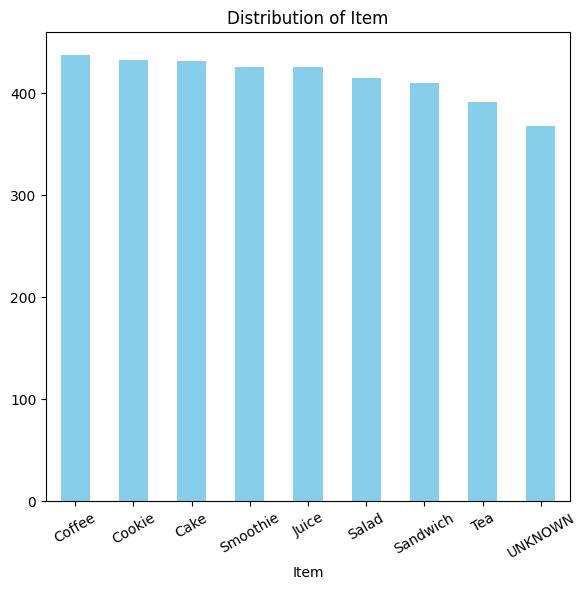


---- Payment Method ----

Payment Method
UNKNOWN           1179
Digital Wallet     867
Credit Card        851
Cash               843
Name: count, dtype: int64


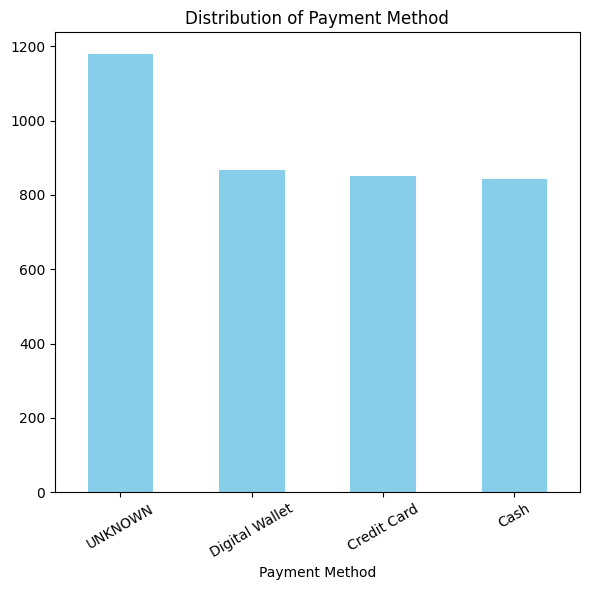


---- Location ----

Location
UNKNOWN     1470
Takeaway    1142
In-store    1128
Name: count, dtype: int64


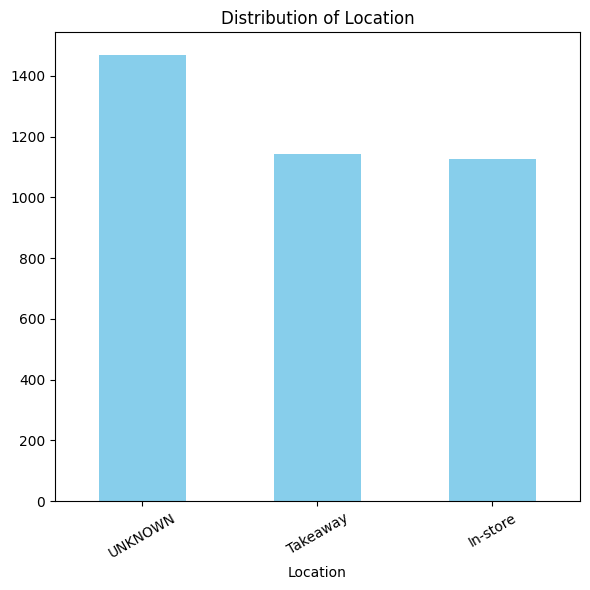

In [6]:
print("\n==== CATEGORICAL VARIABLE ====\n")

# LIST
categorical_cols = ["Item", "Payment Method", "Location"]

for col in categorical_cols:
    
    print(f"\n---- {col} ----\n")
    print(df[col].value_counts())

    # VISUALIZATION
    plt.figure(figsize=(6,6))
    df[col].value_counts().plot(kind="bar", color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# NUMERICAL VARIABLES ANALYSIS


==== NUMERICAL VARIABLE ====


---- Quantity ----

Mean: 3.03
Median: 3.00
Standard Deviation: 1.39
Min: 1.00
Max: 5.00


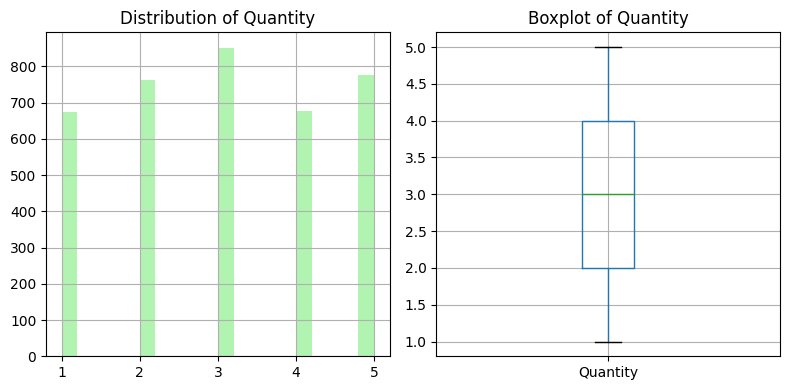


---- Price Per Unit ----

Mean: 2.94
Median: 3.00
Standard Deviation: 1.25
Min: 1.00
Max: 5.00


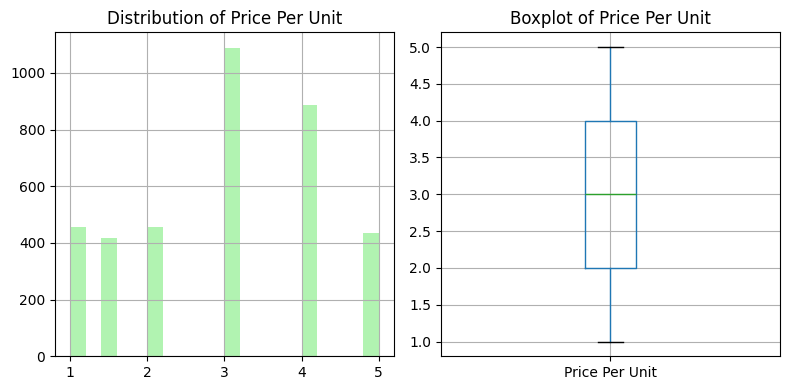


---- Total Spent ----

Mean: 8.92
Median: 8.00
Standard Deviation: 5.84
Min: 1.00
Max: 25.00


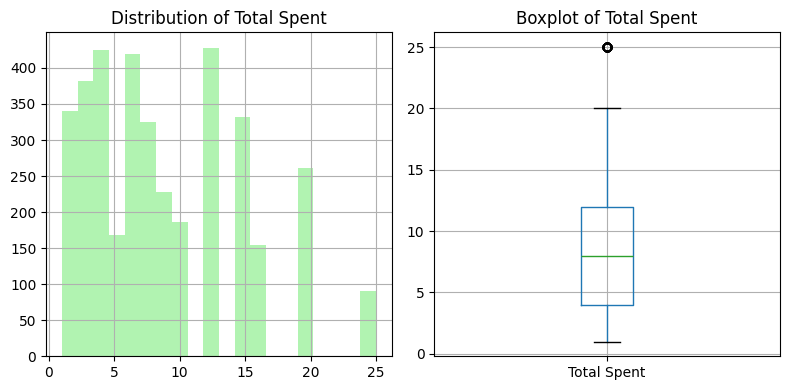

In [7]:
print("\n==== NUMERICAL VARIABLE ====\n")

# LIST
numerical_cols = ["Quantity", "Price Per Unit", "Total Spent"]

for col in numerical_cols:
    
    print(f"\n---- {col} ----\n")
    
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")

    # visualization
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    df[col].hist(bins=20, color="lightgreen", alpha=0.7)
    plt.title(f'Distribution of {col}')

    plt.subplot(1,2,2)
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

# BIVARIATE ANALYSIS 


==== SALES PERFORMANCE BY ITEM ====

          Total Spent  Quantity  Order Count  Average Order Value
Item                                                             
Cake           3930.0      1310          432             9.097222
Coffee         2748.0      1338          438             6.273973
Cookie         1411.0      1303          433             3.258661
Juice          3795.0      1265          426             8.908451
Salad          6271.0      1287          415            15.110843
Sandwich       4991.0      1262          410            12.173171
Smoothie       5079.0      1285          426            11.922535
Tea            1852.5      1190          392             4.725765
UNKNOWN        3278.0      1097          368             8.907609 



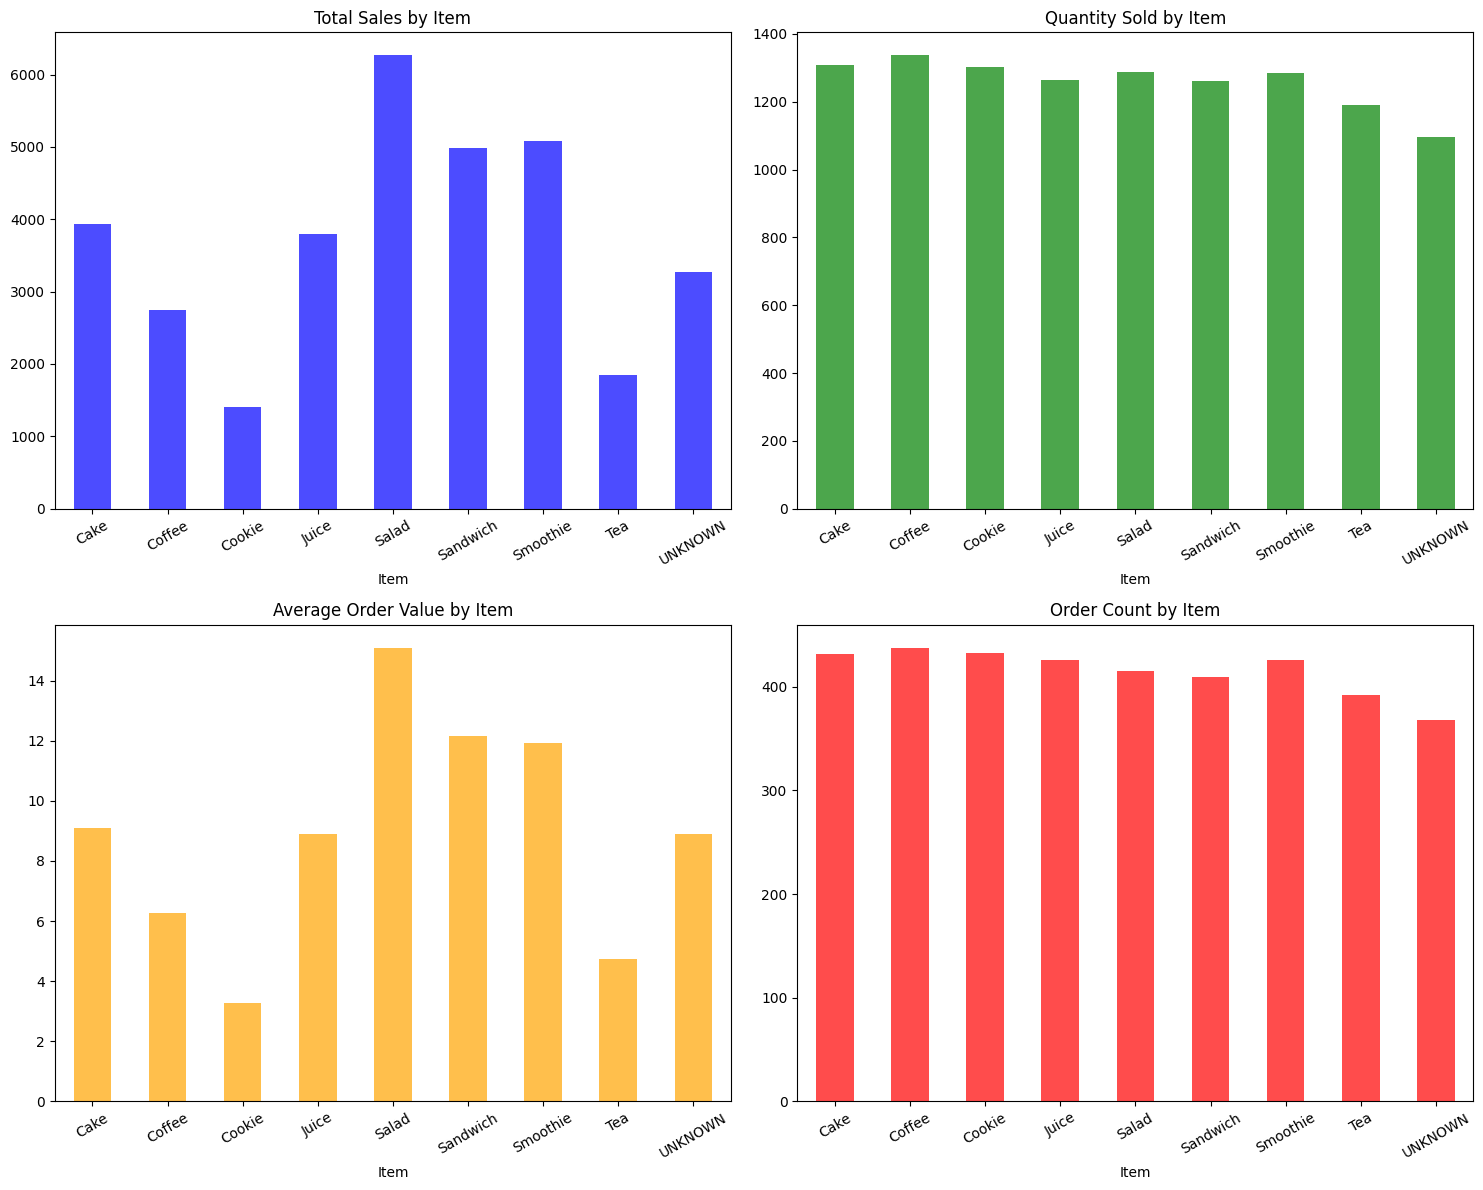

In [8]:
print("\n==== SALES PERFORMANCE BY ITEM ====\n")

item_performance = df.groupby("Item").agg({
    "Total Spent": "sum",
    "Quantity": "sum",
    "Transaction ID": "count"
}).rename(columns={"Transaction ID": "Order Count"})

# Average Order Value
item_performance["Average Order Value"] = (
    item_performance["Total Spent"] / item_performance["Order Count"]
)

print(item_performance, '\n')

# VISUALIZATION
fig, axes = plt.subplots(2,2, figsize=(15,12))

# Total Sales
item_performance["Total Spent"].plot(kind="bar", ax=axes[0,0], color="blue", alpha=0.7)
axes[0,0].set_title("Total Sales by Item")
axes[0,0].tick_params(axis="x", rotation=30)

# Quantity Sold
item_performance["Quantity"].plot(kind="bar", ax=axes[0,1], color="green", alpha=0.7)
axes[0,1].set_title("Quantity Sold by Item")
axes[0,1].tick_params(axis="x", rotation=30)

# Average Order Value
item_performance["Average Order Value"].plot(kind="bar", ax=axes[1,0], color="orange", alpha=0.7)
axes[1,0].set_title("Average Order Value by Item")
axes[1,0].tick_params(axis="x", rotation=30)

# Order Count
item_performance["Order Count"].plot(kind="bar", ax=axes[1,1], color="red", alpha=0.7)
axes[1,1].set_title("Order Count by Item")
axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# TIME SERIES ANALYSIS


=== TIME SERIES ANALYSIS ===

Monthly Trends:
         Total Spent  Quantity  Transaction Count
Month                                            
2023-03       2539.5       880                285
2023-04       2738.0       914                300
2023-05       2668.0       895                301
2023-06       3511.0      1204                378
2023-07       2917.0       993                323
2023-08       2797.5       952                323
2023-09       2820.5       979                315
2023-10       2958.5       953                326
2023-11       2480.0       823                271
2023-12       2649.5       901                304 




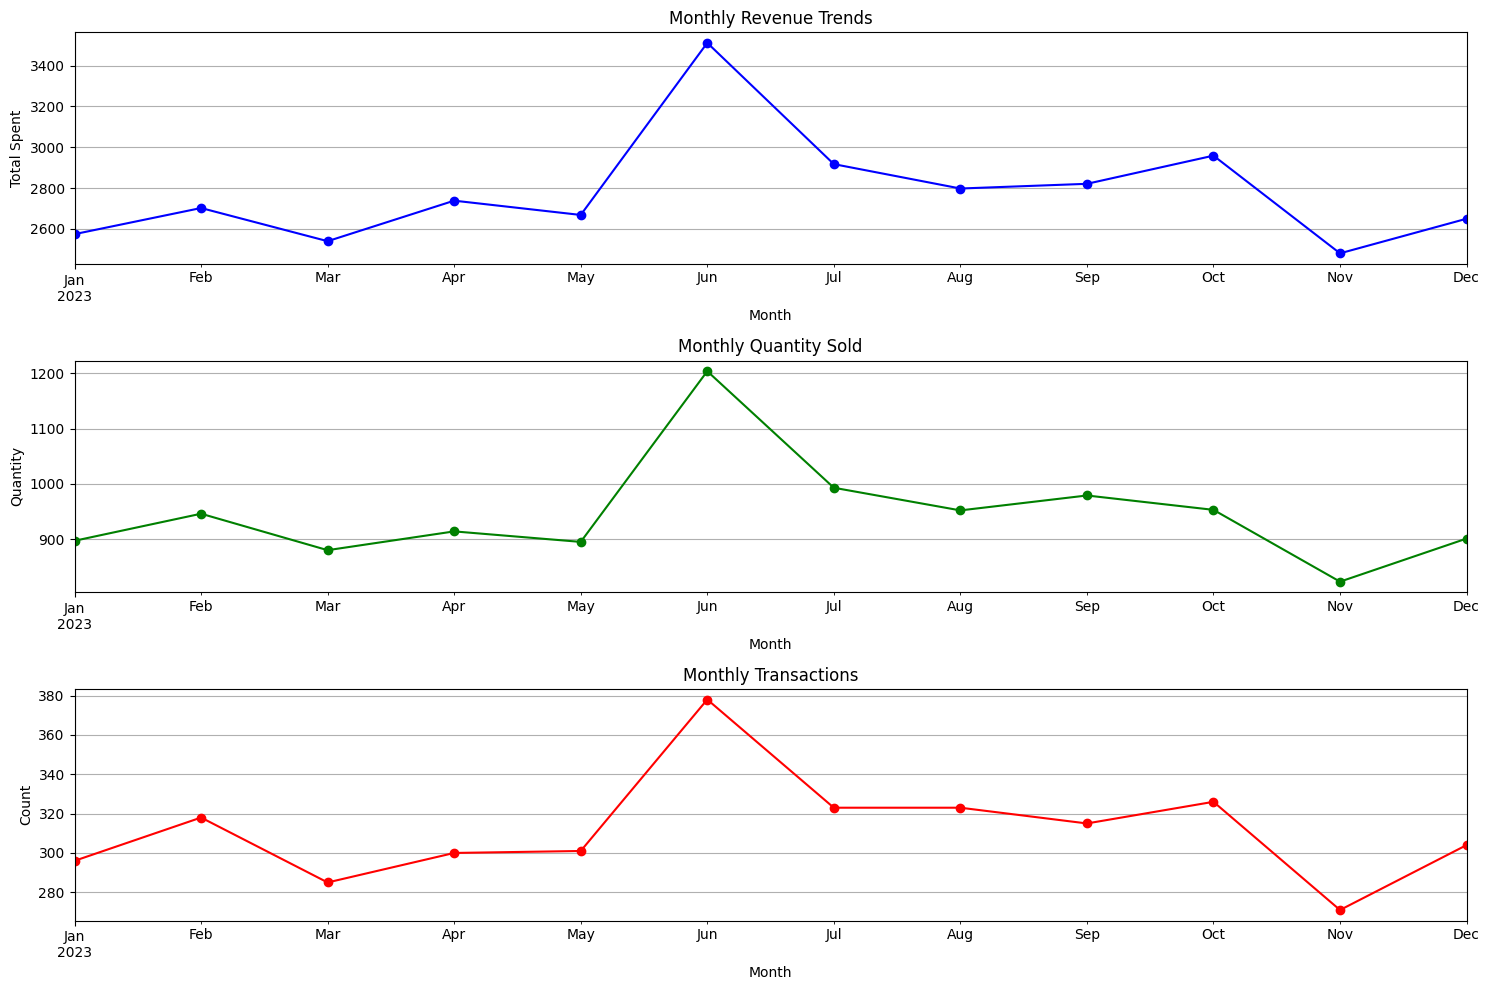

In [9]:
print("\n=== TIME SERIES ANALYSIS ===\n")

# EXTRACTING THE TIME COMPONENTS
df["Month"] = df["Transaction Date"].dt.to_period('M')
df['Date'] = df["Transaction Date"].dt.year

# Monthly trends 
monthly_trends = df.groupby("Month").agg({
    "Total Spent":"sum",
    "Quantity":"sum",
    "Transaction ID": "count"
}).rename(columns={"Transaction ID":"Transaction Count"})

print("Monthly Trends:")
print(monthly_trends.tail(10),'\n\n')

# Visualization
plt.figure(figsize=(15,10))

# Total Spending
plt.subplot(3,1,1)
monthly_trends["Total Spent"].plot(color="blue",marker="o")
plt.title("Monthly Revenue Trends")
plt.ylabel("Total Spent")
plt.grid(True)

# Quantity Sold
plt.subplot(3,1,2)
monthly_trends["Quantity"].plot(color="Green",marker="o")
plt.title("Monthly Quantity Sold")
plt.ylabel("Quantity")
plt.grid(True)

# Transaction Count
plt.subplot(3,1,3)
monthly_trends["Transaction Count"].plot(color="Red",marker="o")
plt.title("Monthly Transactions")
plt.ylabel("Count")
plt.grid(True)

plt.tight_layout()
plt.show()

# ADVANCED ANALYSIS


 === CORRELATION ANALYSIS ===

Correlation Matrix:
                Quantity  Price Per Unit  Total Spent
Quantity        1.000000        0.010387     0.702126
Price Per Unit  0.010387        1.000000     0.654397
Total Spent     0.702126        0.654397     1.000000 




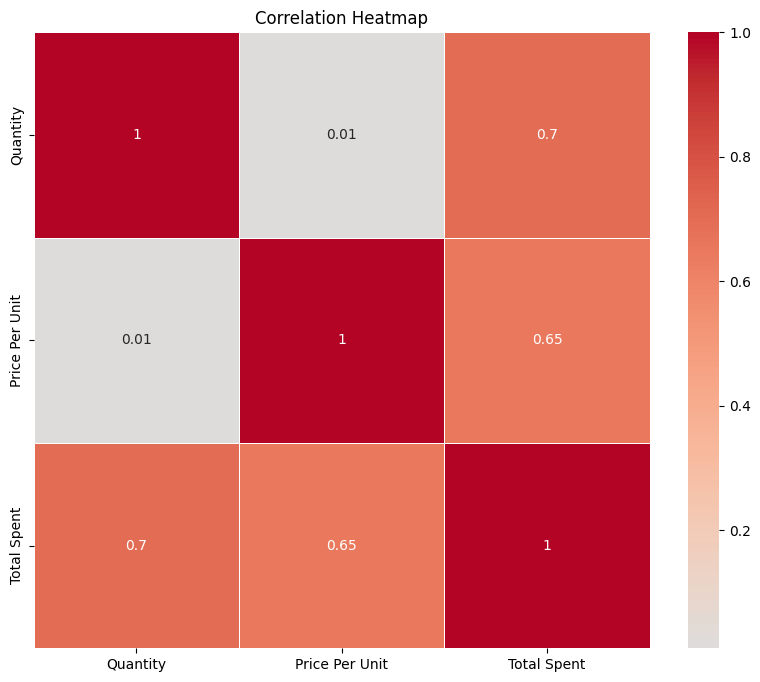

In [10]:
print("\n === CORRELATION ANALYSIS ===\n")

# Selecting numerical columns for correlation
numerical_df = df[["Quantity","Price Per Unit","Total Spent"]]

# Correlation Matrix
correlation_matrix = numerical_df.corr()
print("Correlation Matrix:")
print(correlation_matrix,"\n\n")

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm",center=0,square=True,linewidth=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout
plt.show()


# Customer Segment Analysis

In [11]:
# Create Customer Segment using binning
# Customers are segmented based on their total spending (Total Spent)
# low value: 0-10, medium value: 10-20, high value: 20 and above
df["Customer Segment"] = pd.cut(
    df["Total Spent"],
    bins=[0, 10, 20, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"],
    include_lowest=True
)


 === CUSTOMER SEGMENT ANALYSIS ===

                  Total Revenue  Avg Revenue  Transaction Count  Avg Quantity
Customer Segment                                                             
Low Value               13280.5         5.37               2474          2.47
Medium Value            17800.0        15.15               1175          4.07
High Value               2275.0        25.00                 91          5.00 




C:\Users\Prajwal\AppData\Local\Temp\ipykernel_20096\3550181731.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = df.groupby('Customer Segment').agg({


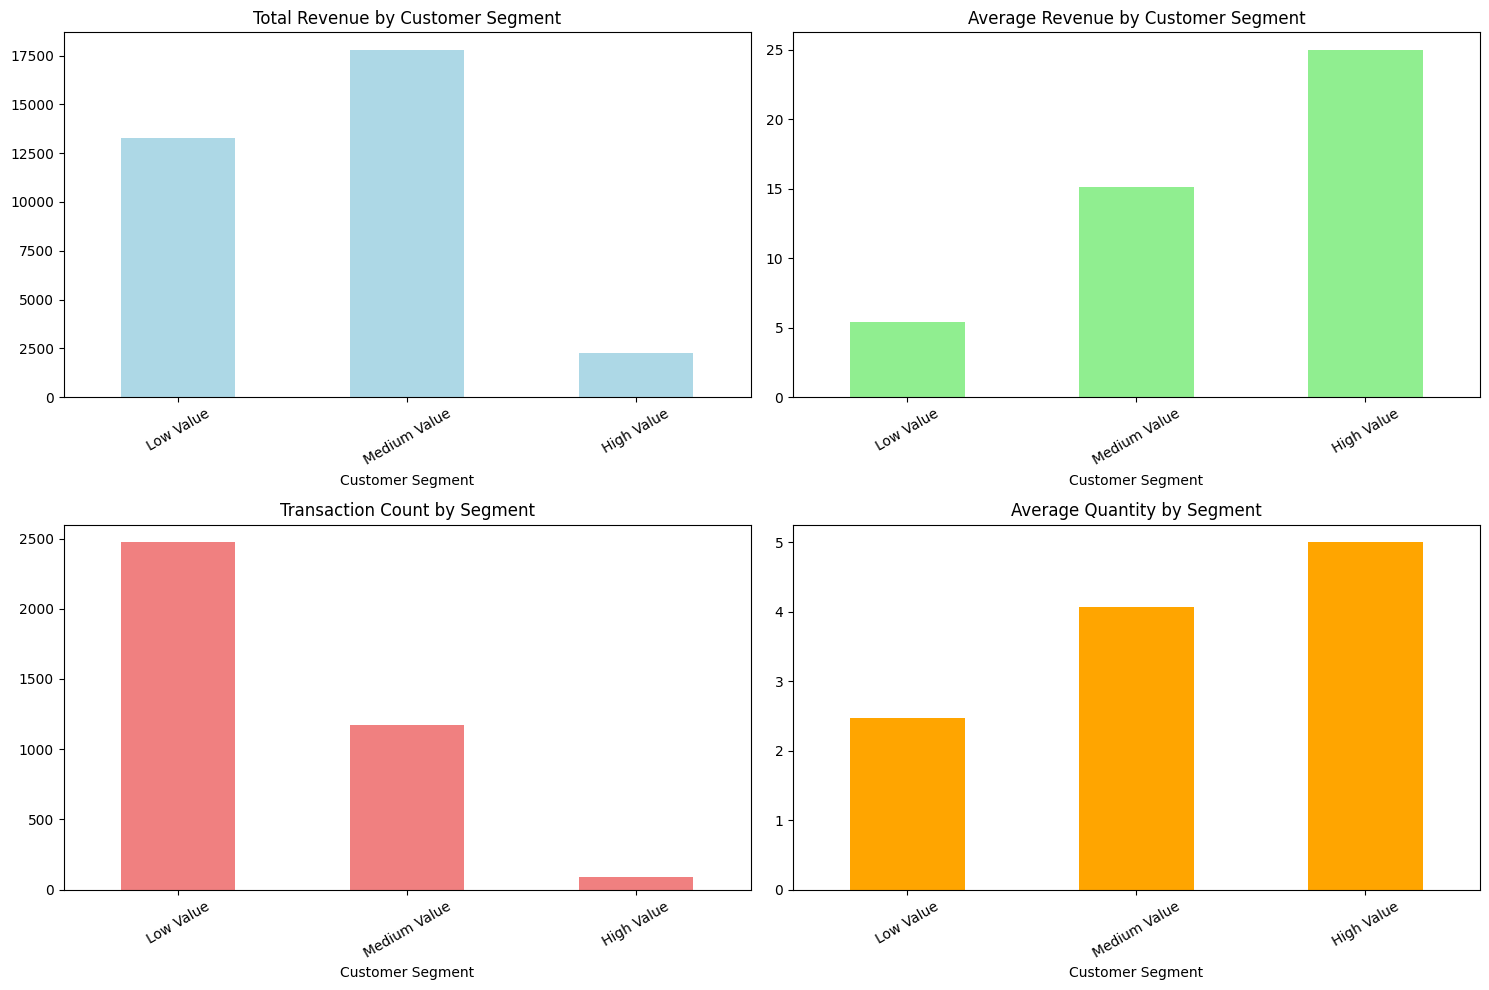

In [12]:
print("\n === CUSTOMER SEGMENT ANALYSIS ===\n")
segment_analysis = df.groupby('Customer Segment').agg({
    'Total Spent': ['sum', 'mean'],
    'Transaction ID': 'count',
    'Quantity': 'mean'
}).round(2)

# Flatten columns
segment_analysis.columns = [
    'Total Revenue',
    'Avg Revenue',
    'Transaction Count',
    'Avg Quantity'
]

print(segment_analysis, "\n\n")

#......................Visualization...................
fig, axes = plt.subplots(2,2, figsize=(15,10))

# Total Revenue
segment_analysis["Total Revenue"].plot(kind='bar',ax=axes[0,0],color="lightblue")
axes[0,0].set_title("Total Revenue by Customer Segment")
axes[0,0].tick_params(axis="x",rotation=30)

# Average Revenue
segment_analysis["Avg Revenue"].plot(kind="bar",ax=axes[0,1],color="lightgreen")
axes[0,1].set_title("Average Revenue by Customer Segment")
axes[0,1].tick_params(axis="x",rotation=30)

# Transaction Count
segment_analysis["Transaction Count"].plot(kind="bar",ax=axes[1,0],color="lightcoral")
axes[1,0].set_title("Transaction Count by Segment")
axes[1,0].tick_params(axis="x",rotation=30)

# Avg Quantity
segment_analysis["Avg Quantity"].plot(kind="bar",ax=axes[1,1],color="orange")
axes[1,1].set_title("Average Quantity by Segment")
axes[1,1].tick_params(axis="x",rotation=30)

plt.tight_layout()
plt.show()

# KEY INSIGHTS SUMMARY

In [13]:
print("\n === KEY INSIGHTS SUMMARY ===\n")

# ------------------- Overall Metrics ---------------------
total_revenue = df["Total Spent"].sum()

total_orders = df["Transaction ID"].nunique()

avg_order_value = total_revenue / total_orders

print("\n OVERALL PERFORMANCE METRICS: \n")
print(f"Total Revenue: ${total_revenue:.2f}")   #.2f is used to format a float value to two decimal places for better readability.
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${avg_order_value:.2f}")

# ------------------------ Top Performing Items ---------------------
top_items = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).head(5)

print("\n TOP PERFORMING ITEMS: \n")
for i, (item, revenue) in enumerate(top_items.items(),1):
    print(f"{i}.{item}: ${revenue:.2f}")

# ------------------------Payment Method Analysis -----------------------
print("\n PAYMENT METHOD ANALYSIS: \n")
payment_stats = df["Payment Method"].value_counts(normalize=True)*100    
for method, percentage in payment_stats.items():
    print(f"{method}:{percentage:.2f}%")

# ------------------------Location Analysis ----------------------
location_sales = df[df["Location"]!="UNKNOWN"].groupby("Location")["Total Spent"].sum()
best_location = location_sales.idxmax()

print(f"\n BEST PERFORMING LOCATION: {best_location}")

# ------------------- Customer Segment ---------------------
segment_revenue = df.groupby("Customer Segment")["Total Spent"].sum()
best_segment = segment_revenue.idxmax()


print(f"\n MOST VALUABLE CUSTOMER SEGMENT: {best_segment}")


 === KEY INSIGHTS SUMMARY ===


 OVERALL PERFORMANCE METRICS: 

Total Revenue: $33355.50
Total Orders: 3740
Average Order Value: $8.92

 TOP PERFORMING ITEMS: 

1.Salad: $6271.00
2.Smoothie: $5079.00
3.Sandwich: $4991.00
4.Cake: $3930.00
5.Juice: $3795.00

 PAYMENT METHOD ANALYSIS: 

UNKNOWN:31.52%
Digital Wallet:23.18%
Credit Card:22.75%
Cash:22.54%

 BEST PERFORMING LOCATION: In-store

 MOST VALUABLE CUSTOMER SEGMENT: Medium Value


C:\Users\Prajwal\AppData\Local\Temp\ipykernel_20096\992661352.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = df.groupby("Customer Segment")["Total Spent"].sum()


# EXPORT RESULTS

In [14]:
# ------------------- EXPORT RESULTS ---------------------
analysis_results = {
    'total_revenue': total_revenue,
    'total_orders': total_orders,
    'avg_order_value': avg_order_value,
    'top_items': top_items.index[0],
    'best_location': best_location,
    'best_customer_segment': best_segment
}

# Convert to DataFrame
results_df = pd.DataFrame([analysis_results])

# save to CSV
results_df.to_csv('eda_results_summary.csv',index=False)

print("\n Analysis summary saved to 'eda_results_summary.csv'")


 Analysis summary saved to 'eda_results_summary.csv'


In [15]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Date,Customer Segment
0,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-11-06,2023-11,2023,Low Value
1,TXN_4433211,UNKNOWN,3,3.0,9.0,UNKNOWN,Takeaway,2023-06-10,2023-06,2023,Low Value
2,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-07-11,2023-07,2023,High Value
3,TXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-03-05,2023-03,2023,Low Value
4,TXN_9437049,Cookie,5,1.0,5.0,UNKNOWN,Takeaway,2023-01-06,2023-01,2023,Low Value
